In [ ]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)

from sklearn.model_selection import train_test_split , cross_val_score

import sys
sys.path.append('../utility')
import plot_utils

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [15]:
train_df = pd.read_csv("/kaggle/input/playground-series-s6e2/train.csv")
test_df = pd.read_csv("/kaggle/input/playground-series-s6e2/test.csv")

train_df.drop("id" , axis = 1, inplace = True)
test_df.drop("id", axis = 1, inplace = True)

In [16]:
train_df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [17]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      630000 non-null  int64  
 1   Sex                      630000 non-null  int64  
 2   Chest pain type          630000 non-null  int64  
 3   BP                       630000 non-null  int64  
 4   Cholesterol              630000 non-null  int64  
 5   FBS over 120             630000 non-null  int64  
 6   EKG results              630000 non-null  int64  
 7   Max HR                   630000 non-null  int64  
 8   Exercise angina          630000 non-null  int64  
 9   ST depression            630000 non-null  float64
 10  Slope of ST              630000 non-null  int64  
 11  Number of vessels fluro  630000 non-null  int64  
 12  Thallium                 630000 non-null  int64  
 13  Heart Disease            630000 non-null  object 
dtypes: f

In [18]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      270000 non-null  int64  
 1   Sex                      270000 non-null  int64  
 2   Chest pain type          270000 non-null  int64  
 3   BP                       270000 non-null  int64  
 4   Cholesterol              270000 non-null  int64  
 5   FBS over 120             270000 non-null  int64  
 6   EKG results              270000 non-null  int64  
 7   Max HR                   270000 non-null  int64  
 8   Exercise angina          270000 non-null  int64  
 9   ST depression            270000 non-null  float64
 10  Slope of ST              270000 non-null  int64  
 11  Number of vessels fluro  270000 non-null  int64  
 12  Thallium                 270000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 26.8 MB


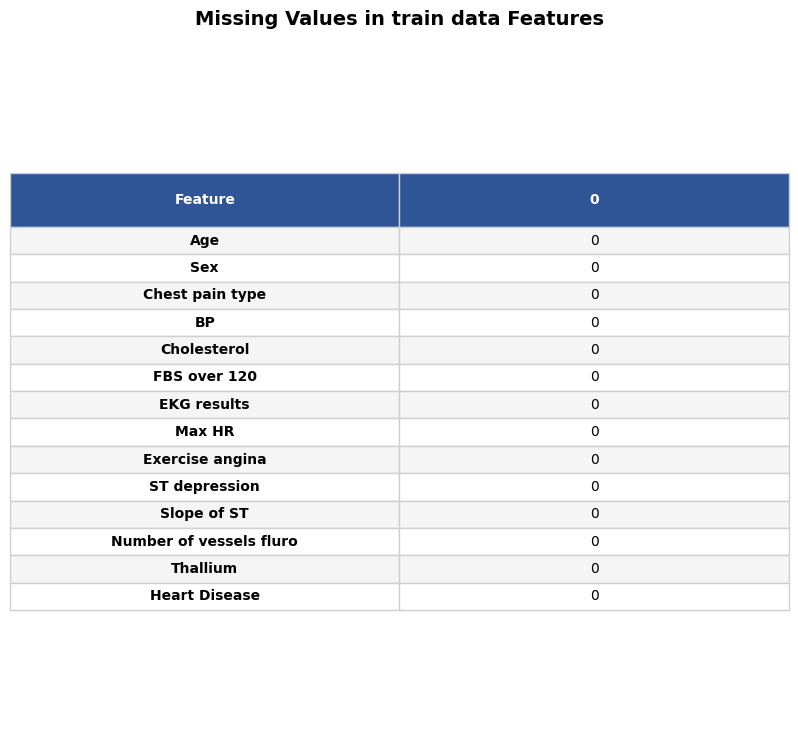

(<Figure size 800x750 with 1 Axes>,
 <Axes: title={'center': 'Missing Values in train data Features'}>)

In [19]:
plot_utils.plot_table(
    train_df.isnull().sum().sort_values(ascending = False).reset_index().rename(
        columns ={
            "index": "Feature",
            "target": "Missing Values"
        }
    ),
    title = "Missing Values in train data Features",
    precision = 3,
    row_colors=("#F5F5F5", "white")
)

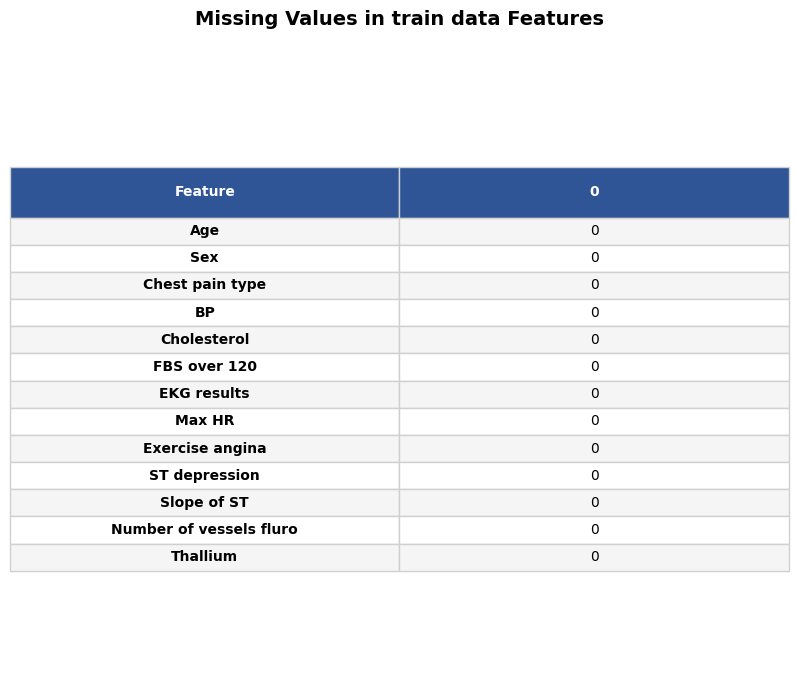

(<Figure size 800x705 with 1 Axes>,
 <Axes: title={'center': 'Missing Values in train data Features'}>)

In [20]:
plot_utils.plot_table(
    test_df.isnull().sum().sort_values(ascending = False).reset_index().rename(
        columns ={
            "index": "Feature",
            "target": "Missing Values"
        }
    ),
    title = "Missing Values in train data Features",
    precision = 3,
    row_colors=("#F5F5F5", "white")
)

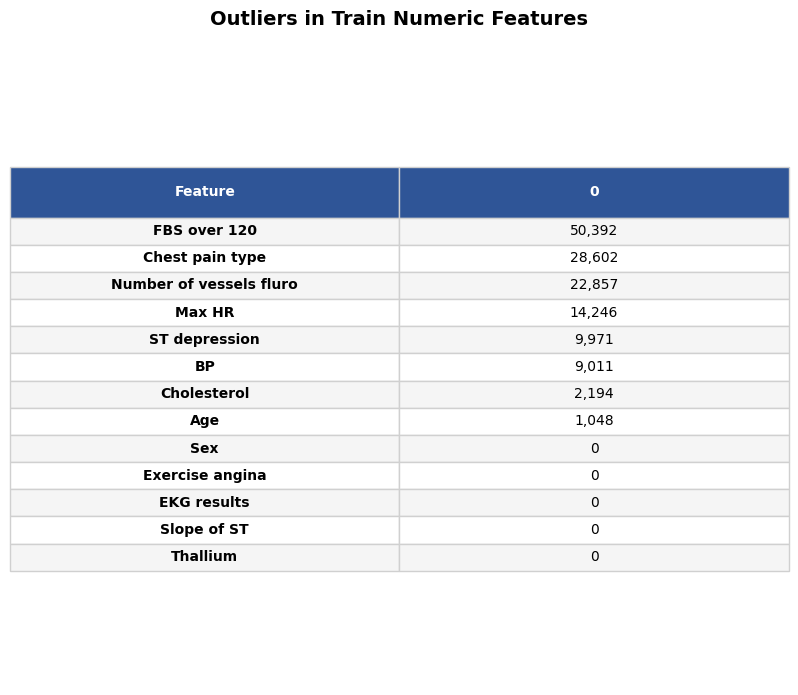

(<Figure size 800x705 with 1 Axes>,
 <Axes: title={'center': 'Outliers in Train Numeric Features'}>)

In [21]:
train_numeric_df = train_df.select_dtypes(include=["int64", "float64"])

Q1 = train_numeric_df.quantile(0.25)
Q3 = train_numeric_df.quantile(0.75)
IQR = Q3 - Q1

train_outliers = (train_numeric_df < (Q1 - 1.5 * IQR)) | (train_numeric_df > (Q3 + 1.5 * IQR)) 

plot_utils.plot_table(
    train_outliers.sum().sort_values(ascending = False).reset_index().rename(
        columns={
            "index": "Feature",
            "target": "Outliers"
        }
    ),
    title = "Outliers in Train Numeric Features",
    precision=3
)

/kaggle/usr/lib/notebooks/alifazelniya/plot_utils/plot_utils.py:524: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


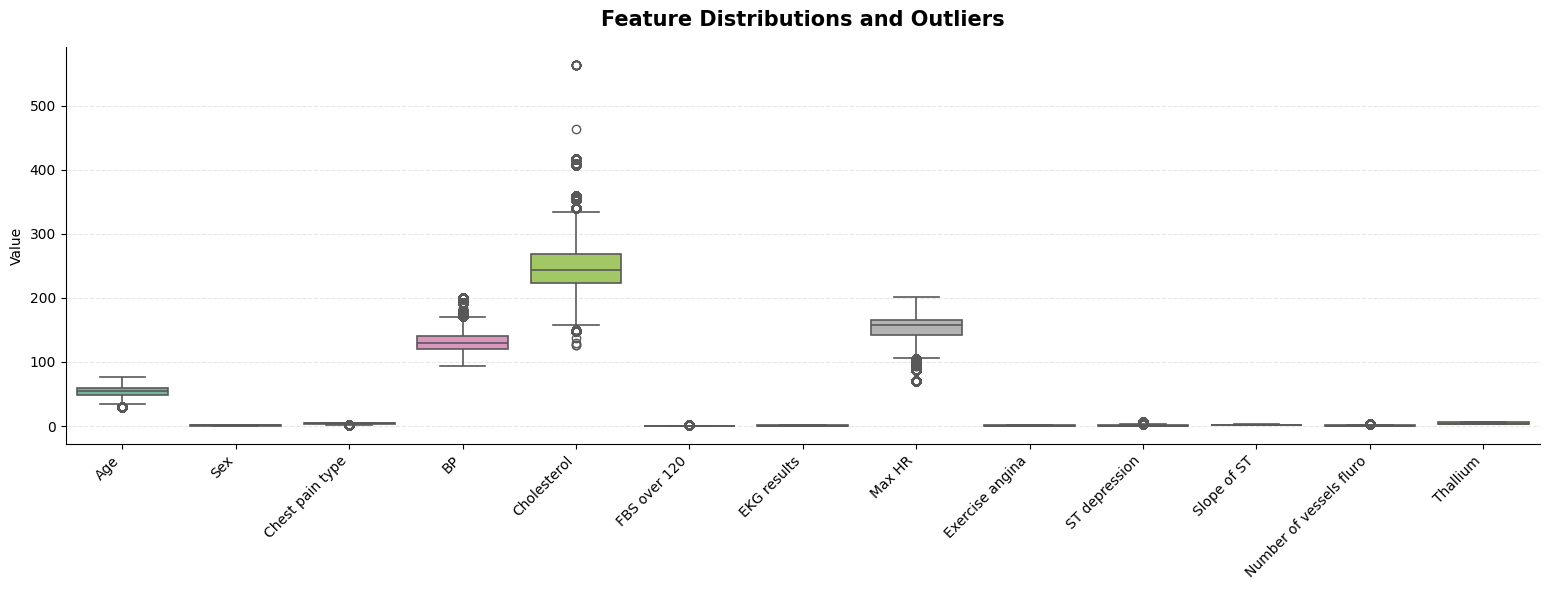

(<Figure size 1560x600 with 1 Axes>,
 <Axes: title={'center': 'Feature Distributions and Outliers'}, ylabel='Value'>)

In [22]:
plot_utils.plot_boxplots(train_numeric_df)

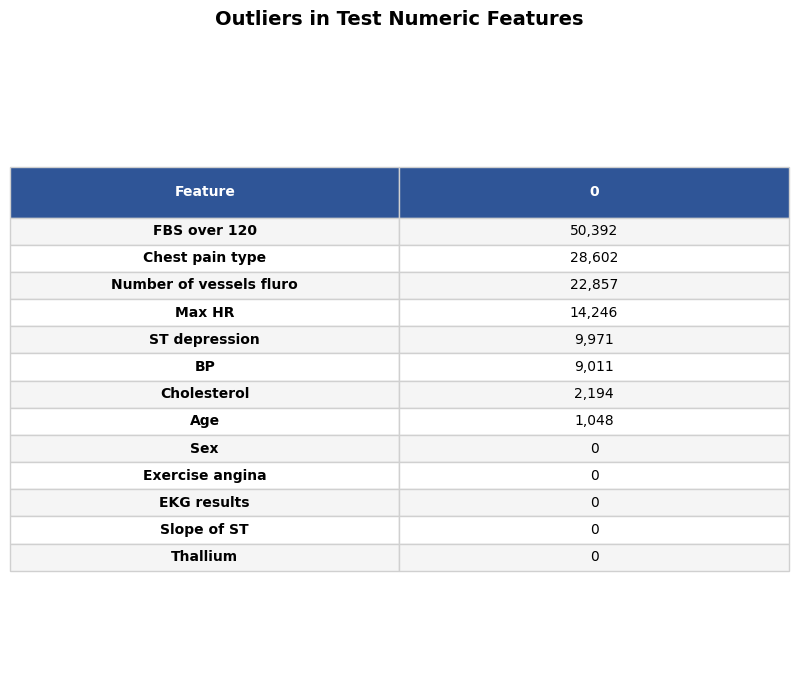

(<Figure size 800x705 with 1 Axes>,
 <Axes: title={'center': 'Outliers in Test Numeric Features'}>)

In [23]:
test_numeric_df = test_df.select_dtypes(include=["int64", "float64"])

Q1 = test_numeric_df.quantile(0.25)
Q3 = test_numeric_df.quantile(0.75)
IQR = Q3 - Q1

test_outliers = (test_numeric_df < (Q1 - 1.5 * IQR)) | (test_numeric_df > (Q3 + 1.5 * IQR)) 

plot_utils.plot_table(
    train_outliers.sum().sort_values(ascending = False).reset_index().rename(
        columns={
            "index": "Feature",
            "target": "Outliers"
        }
    ),
    title = "Outliers in Test Numeric Features",
    precision=3
)

/kaggle/usr/lib/notebooks/alifazelniya/plot_utils/plot_utils.py:524: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


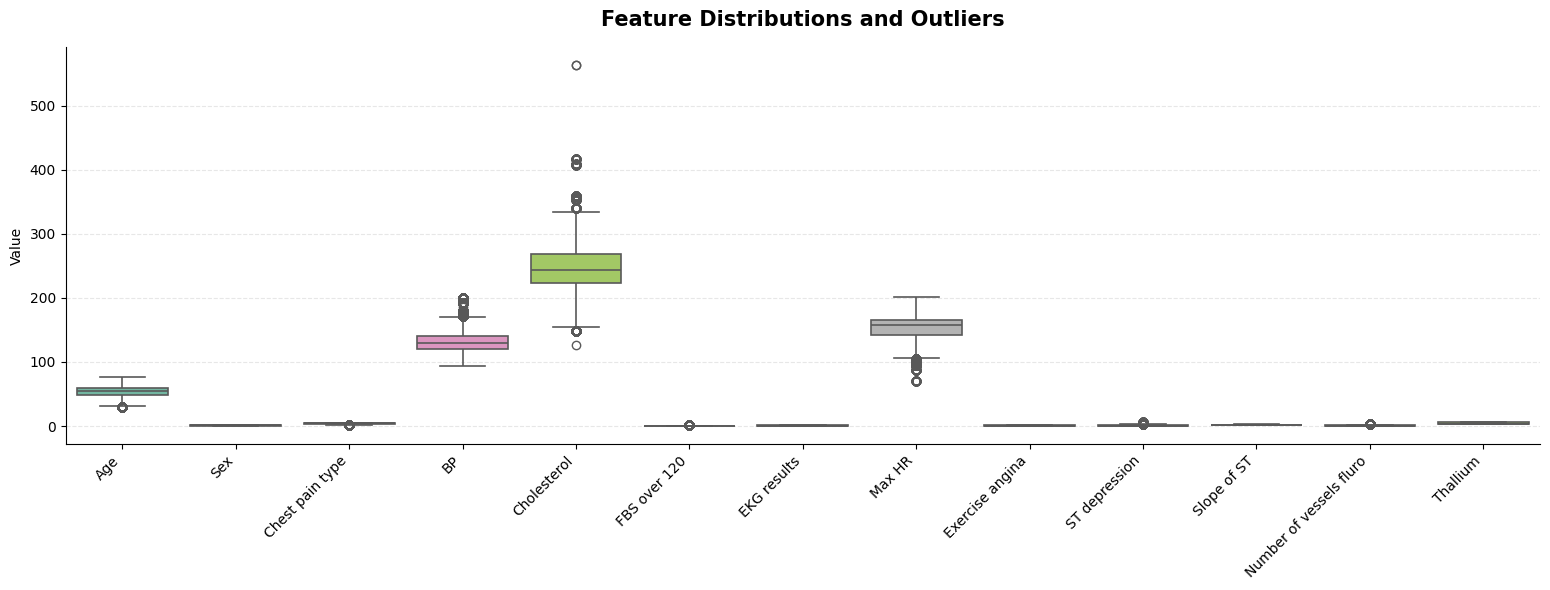

(<Figure size 1560x600 with 1 Axes>,
 <Axes: title={'center': 'Feature Distributions and Outliers'}, ylabel='Value'>)

In [24]:
plot_utils.plot_boxplots(test_numeric_df)

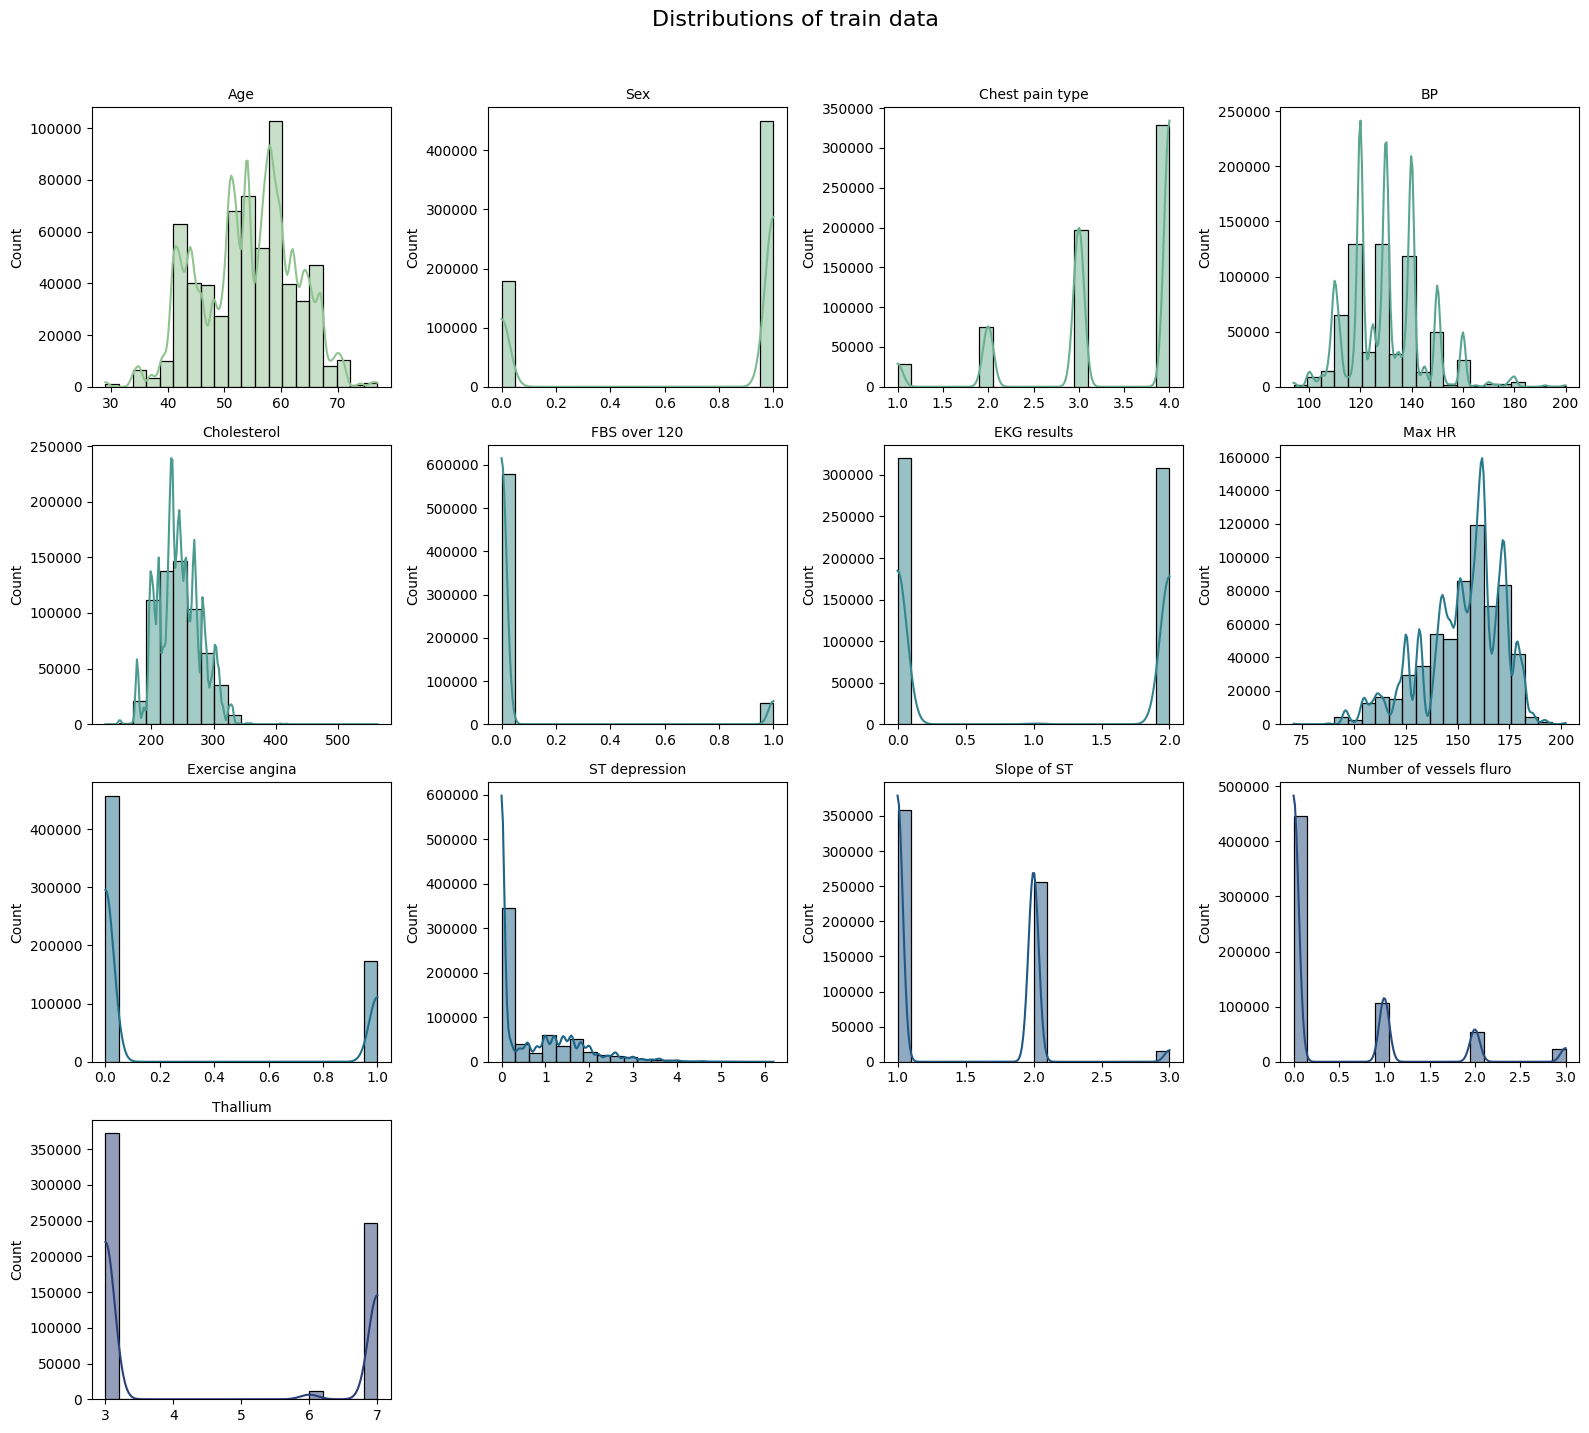

In [26]:
plot_utils.distribution_plot(train_numeric_df, 'train')

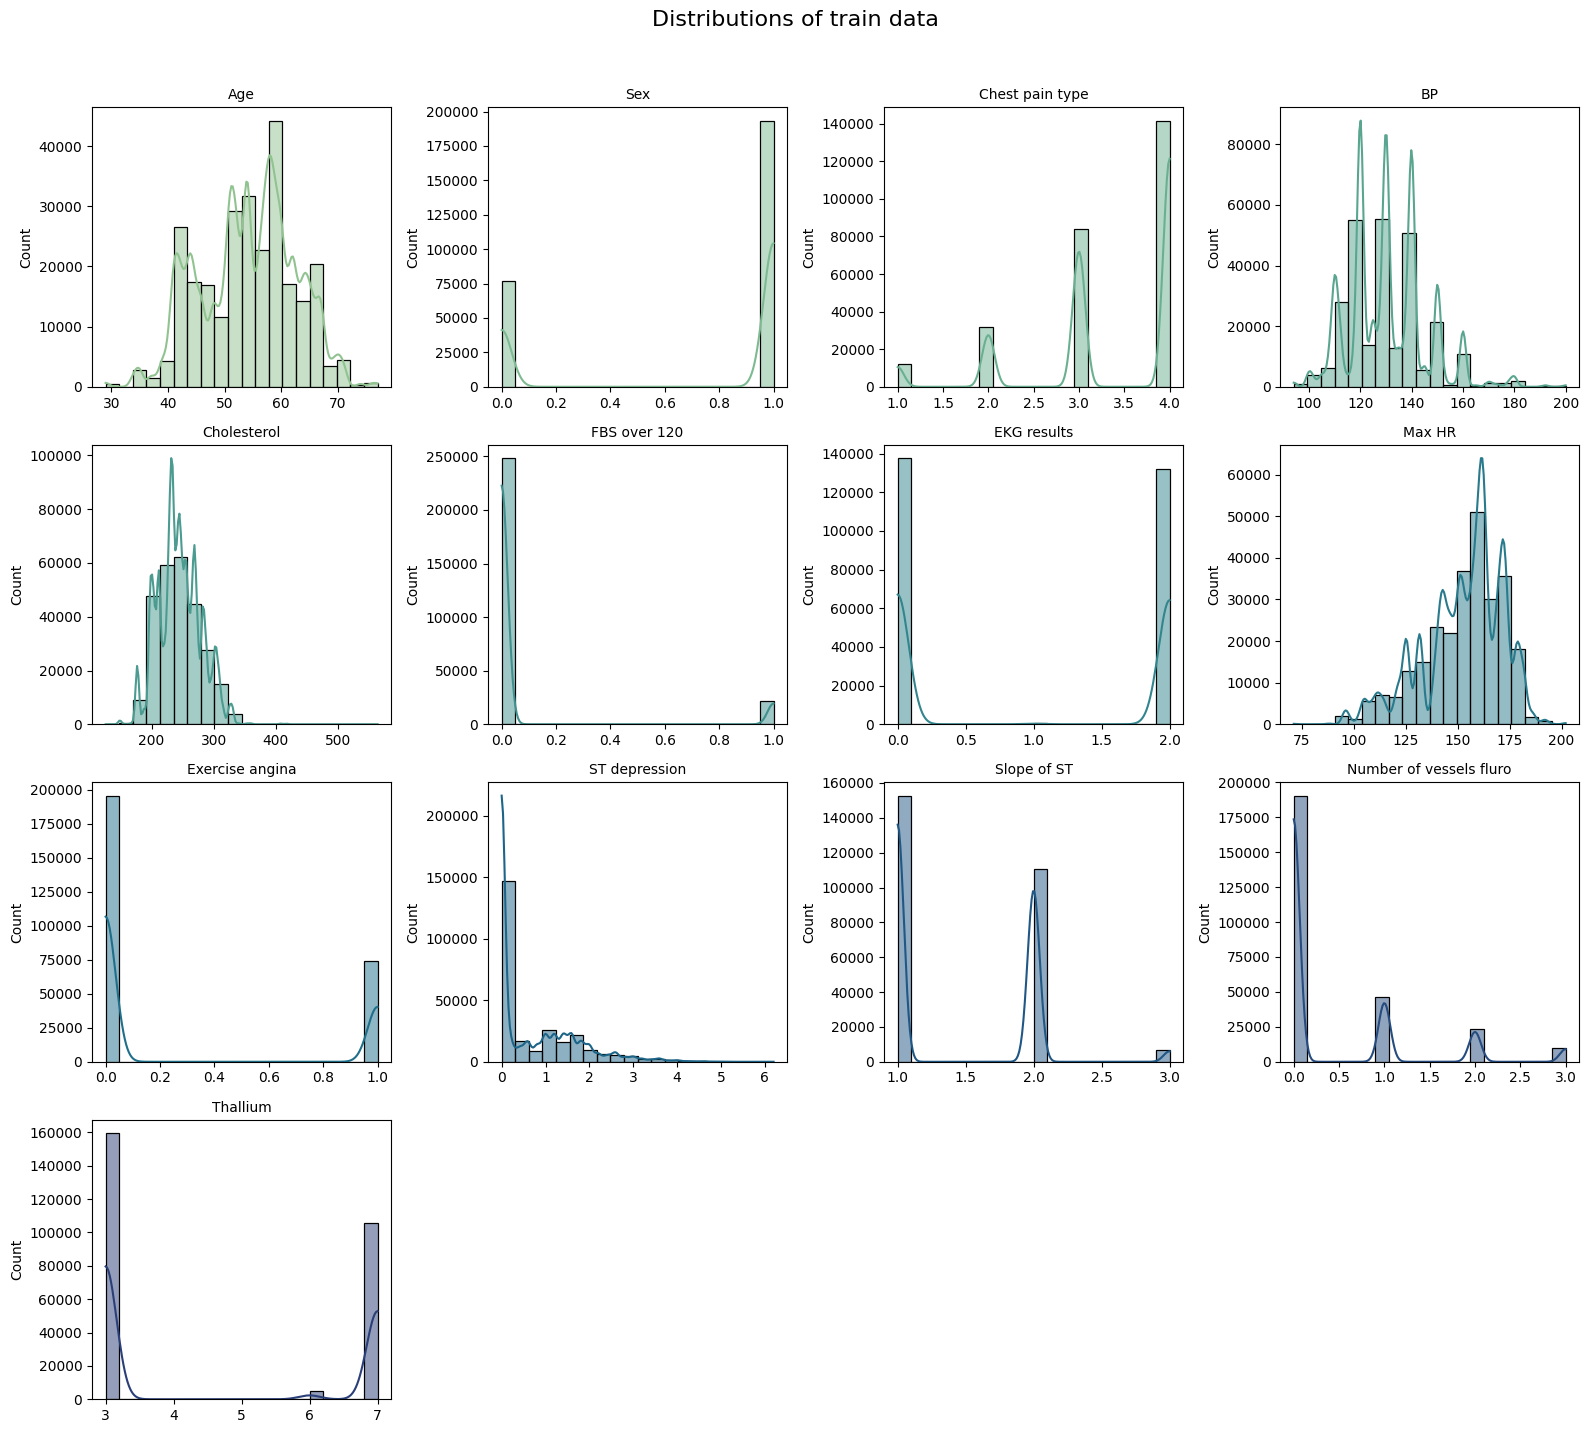

In [27]:
plot_utils.distribution_plot(test_numeric_df, 'train')

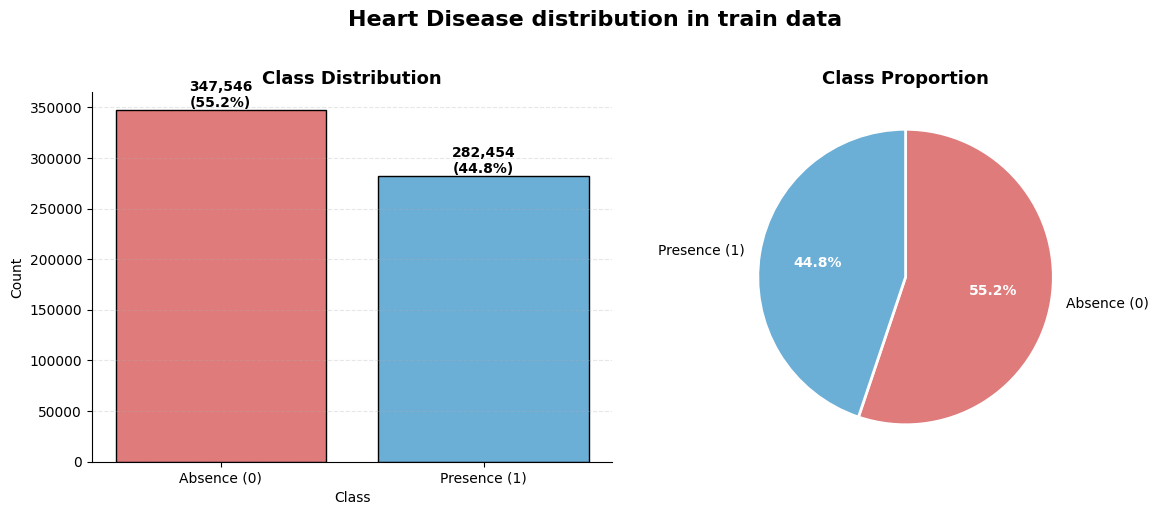

(<Figure size 1200x500 with 2 Axes>,
 array([<Axes: title={'center': 'Class Distribution'}, xlabel='Class', ylabel='Count'>,
        <Axes: title={'center': 'Class Proportion'}>], dtype=object))

In [25]:
plot_utils.plot_target_distribution(train_df, 'Heart Disease', ["Absence (0)", "Presence (1)"], ["#e07b7b", "#6baed6"], title = 'Heart Disease distribution in train data')